In [1]:
#Imports

import numpy as np
from simpeg.electromagnetics import natural_source as nsem
from simpeg import maps
import matplotlib.pyplot as plt
import matplotlib
from simpeg.utils import plot_1d_layer_model
from discretize import TensorMesh
import warnings
warnings.filterwarnings("ignore")
from simpeg import (
    maps, data, data_misfit, regularization,
    optimization, inverse_problem, inversion, directives,utils,
)
from ipywidgets import widgets, interact
from pathlib import Path
from mtpy.core.mt_collection import MTCollection
mtc = MTCollection()
import mtpy as mt
import utm
import matplotlib.gridspec as gridspec


#Solver for Mac
from pymatsolver import Mumps

matplotlib.rcParams['font.size'] = 14

### Geological Figure of Uranium Ore Body

![My Image](Geological_Figures.png)

### Defining Properties and Plotting Layer Model

Text(0.5, 1.0, 'Depth vs. Sigma')

<Figure size 1000x500 with 0 Axes>

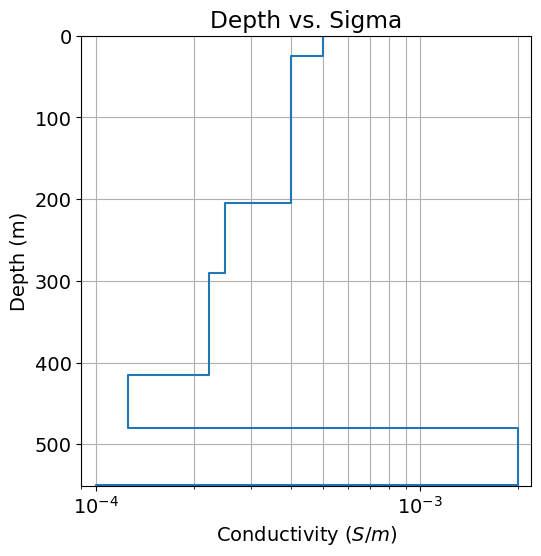

In [2]:
#Geological properties
layer_thicknesses = np.array([25, 180, 85, 125, 65,70,1]) #Thicknesses were obtained from Tuncer, pg. 16
sigma = 1/np.r_[2000.,2500., 4000., 4500.,8000,500,10000]# in S/m # Unknown resistivities/Conductivities had to be inferred Tuncer Fig. 3-17 borehole data


#Plotting 1D Layer Model for visualization
fig = plt.figure(figsize=(10, 5))
ax1 = plot_1d_layer_model(layer_thicknesses, sigma) # figure has base value at log plot
ax1.grid(which="both")
ax1.set_xlabel(r"Conductivity ($S/m$)")
ax1.set_title('Depth vs. Sigma')



  TensorMesh: 454 cells

                      MESH EXTENT             CELL WIDTH      FACTOR
  dir    nC        min           max         min       max      max
  ---   ---  ---------------------------  ------------------  ------
   x    454    -12,000.00          0.00     25.00    400.00    2.00




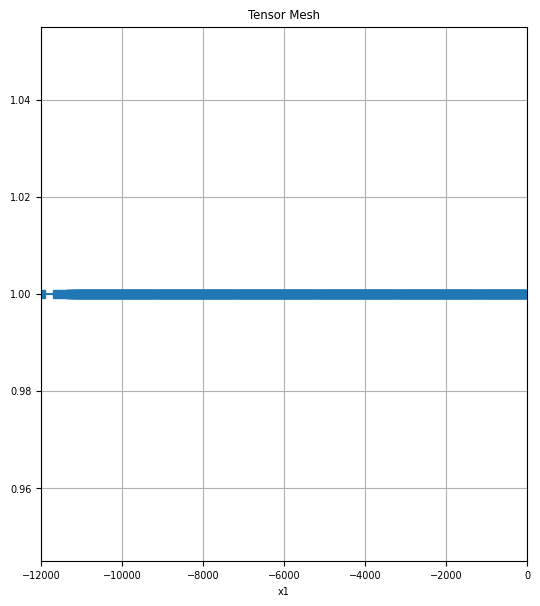

In [27]:
ncx = 450  # number of core mesh cells in x
dx = 25  # base cell width x
npad_x = 4  # number of padding cells in x
exp_x = 2  # expansion rate of padding cells in x

# Use a list of tuples to define cell widths in each direction. Each tuple
# contains the cell width, number of cells and the expansion factor. A
# negative sign is used to indicate an interval where cells widths go
# from largest to smallest.
hx = [(dx, npad_x, -exp_x), (dx, ncx)] #, (dx, npad_x, exp_x)]

# We can use flags 'C', '0' and 'N' to shift the xyz position of the mesh
# relative to the origin
mesh = TensorMesh([hx], x0 = "N")

# We can apply the plot_grid method and output to a specified axes object
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111)
mesh.plot_grid(ax=ax, nodes="True")
ax.set_xbound(mesh.x0[0], mesh.x0[0] + np.sum(mesh.h[0]))
ax.set_title("Tensor Mesh")
print(mesh)

In [57]:
sigma_background = 1/2000
model = np.ones(mesh.n_cells) * sigma_background  # np.zeros(len(x_cells)) 

layer_depths = np.array([25, 205, 290, 415, 480, 550])
    
# define a boxcar 
layer_1_model = (mesh.cell_centers >= -layer_depths[0])
layer_2_model = (mesh.cell_centers < -layer_depths[0]) & (mesh.cell_centers >= -layer_depths[1])
layer_3_model = (mesh.cell_centers < -layer_depths[1]) & (mesh.cell_centers >= -layer_depths[2])
layer_4_model = (mesh.cell_centers < -layer_depths[2]) & (mesh.cell_centers >= -layer_depths[3])
layer_5_model = (mesh.cell_centers < -layer_depths[3]) & (mesh.cell_centers >= -layer_depths[4])
layer_6_model = (mesh.cell_centers < -layer_depths[4]) & (mesh.cell_centers >= -layer_depths[5])
layer_7_model = (mesh.cell_centers < -layer_depths[5])




layer_7_model


model[layer_7_model] = 10
model

array([1.e+01, 1.e+01, 1.e+01, 1.e+01, 1.e+01, 1.e+01, 1.e+01, 1.e+01,
       1.e+01, 1.e+01, 1.e+01, 1.e+01, 1.e+01, 1.e+01, 1.e+01, 1.e+01,
       1.e+01, 1.e+01, 1.e+01, 1.e+01, 1.e+01, 1.e+01, 1.e+01, 1.e+01,
       1.e+01, 1.e+01, 1.e+01, 1.e+01, 1.e+01, 1.e+01, 1.e+01, 1.e+01,
       1.e+01, 1.e+01, 1.e+01, 1.e+01, 1.e+01, 1.e+01, 1.e+01, 1.e+01,
       1.e+01, 1.e+01, 1.e+01, 1.e+01, 1.e+01, 1.e+01, 1.e+01, 1.e+01,
       1.e+01, 1.e+01, 1.e+01, 1.e+01, 1.e+01, 1.e+01, 1.e+01, 1.e+01,
       1.e+01, 1.e+01, 1.e+01, 1.e+01, 1.e+01, 1.e+01, 1.e+01, 1.e+01,
       1.e+01, 1.e+01, 1.e+01, 1.e+01, 1.e+01, 1.e+01, 1.e+01, 1.e+01,
       1.e+01, 1.e+01, 1.e+01, 1.e+01, 1.e+01, 1.e+01, 1.e+01, 1.e+01,
       1.e+01, 1.e+01, 1.e+01, 1.e+01, 1.e+01, 1.e+01, 1.e+01, 1.e+01,
       1.e+01, 1.e+01, 1.e+01, 1.e+01, 1.e+01, 1.e+01, 1.e+01, 1.e+01,
       1.e+01, 1.e+01, 1.e+01, 1.e+01, 1.e+01, 1.e+01, 1.e+01, 1.e+01,
       1.e+01, 1.e+01, 1.e+01, 1.e+01, 1.e+01, 1.e+01, 1.e+01, 1.e+01,
      

In [50]:
model = np.array(mesh.nodes)  # np.zeros(len(x_cells)) 

layer_depths = np.array([25, 205, 290, 415, 480, 550])
    
# define a boxcar 
layer_1_model = (model >= -layer_depths[0])

layer_2_model = (model < -layer_depths[0]) & (model >= -layer_depths[1])

layer_3_model = (model < -layer_depths[1]) & (model >= -layer_depths[2])

layer_4_model = (model < -layer_depths[2]) & (model >= -layer_depths[3])

layer_5_model = (model < -layer_depths[3]) & (model >= -layer_depths[4])

layer_6_model = (model < -layer_depths[4]) & (model >= -layer_depths[5])

layer_7_model = (model < -layer_depths[5])




layer_7_model

array([ True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,  True,  True,  True,  True,  True,  True,  True,
        True,  True,

In [62]:
#Survey Properties
frequencies = np.r_[7.68*10**3, 5.12*10**3, 3.84*10**3, 1.28*10**3,
    9.59*10**2, 6.4*10**2, 4.64*10**2, 3.36*10**2, 2.4*10**2, 1.77*10**2, 1.28*10**2,
    9.699*10**1,8.1*10**1,7.1*10**1,6.1*10**1,5.1*10**1,4.1*10**1,3.275*10**1,2.225*10**1,1.512*10**1,1.025*10**1,
    6.937,4.875]  # frequencies in Hz # Obtained from Cameco Data, Line 304

max_skin_depth = 503*np.sqrt(10000/frequencies.min())
min_skin_depth = 503*np.sqrt(2000/frequencies.max())
min_skin_depth, max_skin_depth

#Setting up mesh
# mesh = TensorMesh([max_skin_depth*np.ones(100)] , origin="0")
# fig, ax = plt.subplots(1,1, figsize = (10,4))
# mesh.plot_image(true_model,ax= ax, grid=True)
# mesh

(np.float64(256.6861126291539), np.float64(22781.413926989266))

In [ ]:
max_skin_depth/

In [58]:
max_skin_depth, min_skin_depth

(np.float64(10188.158032861686), np.float64(573.9675967189553))

### Setting up 1D MT Simulation

In [17]:

############

#wire_map = maps.Wires(("sigma", mesh.nC), ("t", mesh.nC - 1)) # Mapping class for organizing multiple parameter types into a single model. m = [sigma | t]
sigma_map = maps.ExpMap(nP=mesh.nC)# * wire_map.sigma # Extracting sigma from wire_map
#layer_map = maps.ExpMap(nP=mesh.nC - 1) * wire_map.t # Extracting layers t from wire_map


model_mapping = maps.IdentityMap(nP=len(sigma))

#Setting up RX locations 
rx_loc_single = np.array([[1.0]])
receivers_list = [
    nsem.receivers.Impedance(rx_loc_single, orientation="xy", component="real"),# Using RX_loc for first receiver 1/17
    nsem.receivers.Impedance(rx_loc_single, orientation="xy", component="imag"),
]

source_list = []
for freq in frequencies:
    source_list.append(nsem.sources.Planewave(receivers_list, freq)) # Setting sources as plane waves at each specified frequencies 

survey = nsem.survey.Survey(source_list) #Creating survey object with given sources form source_list

simulation = nsem.Simulation1DElectricField(mesh,
    survey=survey, 
    sigmaMap=sigma_map,
    solver = Mumps)

true_model = np.log(sigma) * np.ones()

dpred = simulation.dpred(true_model)


ValueError: operands could not be broadcast together with shapes (7,) (558,) 

In [ ]:
dpred

In [ ]:
mesh

### Test Inversion

In [ ]:
#Setting geometry parameters.
dz = 25 # First layer depth
n_layer = 6 # Number of Layers
z_factor = 2.3 # Layer depth increase factor

#layer_thicknesses_inv = dz * z_factor**np.arange(n_layer-1) # Layer thicknesses
layer_thicknesses_inv=  np.array([25, 180, 85, 125, 135]) # Need to ask if it is ok to use predetermined thicknesses (Could be too much prior knowledge)??? # Including the halfspace...

In [ ]:
#Defining inversion function
def run_smooth_inversion(
    dobs,
    standard_deviation,
    rho_0,
    rho_ref,
    maxIter=10,
    maxIterCG=30,
    maxIterLS=30,
    alpha_s=1e-10,
    alpha_z=1,
    beta0_ratio=1,
    coolingFactor=2,
    coolingRate=1,
    chi_factor=1,
    p_s=0, 
    p_z=0,
    
):
    mesh_inv = TensorMesh([(np.r_[layer_thicknesses_inv, layer_thicknesses_inv[-1]])], "N")
    receivers_list = [
    nsem.receivers.Impedance(rx_loc_single, orientation="xy", component="apparent_resistivity"),
    nsem.receivers.Impedance(rx_loc_single, orientation="xy", component="phase"),
    ]

    source_list = []
    for freq in frequencies:
        source_list.append(nsem.sources.Planewave(receivers_list, freq))

    survey = nsem.survey.Survey(source_list)

    sigma_map = maps.ExpMap(nP=len(layer_thicknesses_inv)+1)
    simulation = nsem.simulation_1d.Simulation1DRecursive(
        survey=survey, 
        sigmaMap=sigma_map,
        thicknesses=layer_thicknesses_inv,
    )
    # Define the data 
    data_object = data.Data(survey, dobs=dobs, standard_deviation=standard_deviation)    
    
    # Initial model
    m0 = np.ones(len(layer_thicknesses_inv)+1) * np.log(1./rho_0)
    
    # Reference model
    mref = np.ones(len(layer_thicknesses_inv)+1) * np.log(1./rho_ref)    
    
    dmis = data_misfit.L2DataMisfit(simulation=simulation, data=data_object)

    # Define the regularization (model objective function)
    reg = regularization.Sparse(
        mesh_inv, alpha_s=alpha_s, alpha_x=alpha_z, 
        reference_model=mref,
        reference_model_in_smooth=False,
        mapping=maps.IdentityMap(mesh=mesh_inv),
    )

    # Define how the optimization problem is solved. Here we will use an inexact
    # Gauss-Newton approach that employs the conjugate gradient solver.
    opt = optimization.InexactGaussNewton(
    maxIter=maxIter,
    maxIterCG=maxIterCG,
    maxIterLS=maxIterLS,
    )


    # Define the inverse problem
    inv_prob = inverse_problem.BaseInvProblem(dmis, reg, opt)

    #######################################################################
    # Define Inversion Directives
    # ---------------------------
    #
    # Here we define any directives that are carried out during the inversion. This
    # includes the cooling schedule for the trade-off parameter (beta), stopping
    # criteria for the inversion and saving inversion results at each iteration.
    #

    # Defining a starting value for the trade-off parameter (beta) between the data
    # misfit and the regularization.
    starting_beta = directives.BetaEstimate_ByEig(beta0_ratio=beta0_ratio)

    # Set the rate of reduction in trade-off parameter (beta) each time the
    # the inverse problem is solved. And set the number of Gauss-Newton iterations
    # for each trade-off paramter value.
    beta_schedule = directives.BetaSchedule(coolingFactor=coolingFactor, coolingRate=coolingRate)
    save_dictionary = directives.SaveOutputDictEveryIteration()
    save_dictionary.outDict = {}
    # Setting a stopping criteria for the inversion.
    target_misfit = directives.TargetMisfit(chifact=chi_factor)
    precond = directives.UpdatePreconditioner()

    # The directives are defined as a list.
    directives_list = [
        precond,
        starting_beta,
        beta_schedule,
        target_misfit,
        save_dictionary
    ]

    #####################################################################
    # Running the Inversion
    # ---------------------
    #
    # To define the inversion object, we need to define the inversion problem and
    # the set of directives. We can then run the inversion.
    #

    # Here we combine the inverse problem and the set of directives
    inv = inversion.BaseInversion(inv_prob, directives_list)

    # Run the inversion
    recovered_model = inv.run(m0)    
    
    return recovered_model, save_dictionary.outDict

In [ ]:
relative_error_rho = 0.1
floor_phase = 1.
rho_app = dpred.reshape((len(frequencies), 2))[:,0]
phase = dpred.reshape((len(frequencies), 2))[:,1]
standard_deviation = np.c_[abs(rho_app)*relative_error_rho, np.ones(len(phase))*floor_phase].flatten()

output_dict ={}
recovered_model, output_dict = run_smooth_inversion(
    dpred,
    standard_deviation,
    rho_0 = 2000,
    rho_ref= 2500,
    maxIter=22,
    maxIterCG=30,
    maxIterLS=50, 
    alpha_s=1e-1,
    alpha_z=2,
    beta0_ratio=1e2,
    coolingFactor=2,
    coolingRate=1,
    chi_factor=1
)

In [ ]:
target_misfit = dpred.size
iterations = list(output_dict.keys())
n_iteration = len(iterations)
phi_ds = np.zeros(n_iteration)
phi_ms = np.zeros(n_iteration)
betas = np.zeros(n_iteration)
for ii, iteration in enumerate(iterations):
    phi_ds[ii] = output_dict[iteration]['phi_d']
    phi_ms[ii] = output_dict[iteration]['phi_m']
    betas[ii] = output_dict[iteration]['beta']

In [ ]:
matplotlib.rcParams['font.size'] = 14
def tikhonov_curve(iteration, scale='log'):
    fig, ax = plt.subplots(1,1, figsize=(5,5))
    ax.plot(phi_ms, phi_ds)
    ax.plot(phi_ms[iteration-1], phi_ds[iteration-1], 'ro')
    ax.set_xlabel(r"$\phi_m$")
    ax.set_ylabel(r"$\phi_d$")
    if scale == 'log':
        ax.set_xscale('log')
        ax.set_yscale('log')
    xlim = ax.get_xlim()
    ax.plot(xlim, np.ones(2) * target_misfit, '--')
    ax.set_title("Iteration={:d}, Beta = {:.1e}".format(iteration, betas[iteration-1]))
    ax.set_xlim(xlim)
    plt.show()

In [ ]:
from ipywidgets import interact, widgets
Q_iter = interact(
    tikhonov_curve, 
    iteration=widgets.IntSlider(min=1, max=int(n_iteration), value=n_iteration),
    scale=widgets.RadioButtons(options=['linear', 'log'])
)

In [ ]:
#Plotting
iteration = 12
dpred = output_dict[iteration]['dpred']
m = output_dict[iteration]['m']
fig = plt.figure(figsize=(16, 5))
gs = gridspec.GridSpec(1, 5, figure=fig)

ax0 = fig.add_subplot(gs[0, 0])
plot_1d_layer_model(layer_thicknesses, 1/sigma) # figure has base value at log plot
plot_1d_layer_model(
    layer_thicknesses_inv,
    1.0 / np.exp(m),
    ax=ax0,
    color="k",
    label=r"$m_{Inv}$",
    linestyle="--",
)
ax0.legend()
ax0.set_xlabel(r"Resistivity [$\Omega$m]")
ax0.set_title('Model from iteration ' + str(iteration), fontsize=14)
ax0.grid(True, which='both', alpha=0.5)


ax = fig.add_subplot(gs[0, 2:])
ax.loglog(1./frequencies, dpred.reshape((len(frequencies), 2))[:,0], color='C0', label=r'$d_{pred}$ ($\rho_{a}$)')

ax_1 = ax.twinx()
ax_1.plot(1./frequencies, dpred.reshape((len(frequencies), 2))[:,1], color='C1', label=r'$d_{pred}$ ($\Phi$)')
ax.set_xlabel("Period [s]")
ax.grid(True, which='both', alpha=0.5)
ax.set_ylabel(r"Apparent resistivity [$\Omega$m]")
ax_1.set_ylabel(r"Phase [$\degree$]")
# ax.legend(bbox_to_anchor=(1.1,1))
ax.legend(loc=2)
ax_1.legend(loc=1)
plt.show()